# Goal: try to predict validation `per_sample` parameters through a model (here RandomForest) trained on input features (`cytof_init`) -> parameter deviations

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

from common import MODEL_FEATURE_PREFIX, training_samples, val_samples, PER_SAMPLE_OUTFILE_PARS
from dmm import MEDIAN_FEATURE_PREFIX
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files
from dmm.petab_subproblem import load_petab
from cytof.problem import CytofProblem
from evaluation_utils import generate_per_sample_pretraining_problems
from amici.petab.simulations import rdatas_to_simulation_df
from dmm.analysis import process_simulation

# Set random seed
np.random.seed(42)

# Get overall list of samples (cell-lines)
conf = Conf(model="EGFR_MAPK", data="dream_cytof", samples="0of5")

samples_train, samples_val = training_samples(conf), val_samples(conf)
sample_name_list = sorted(samples_train + samples_val)

# Load per sample parameters
per_sample_parameter_file = PER_SAMPLE_OUTFILE_PARS.format(
    **{**conf, "sample": "{sample}"}
)

pretrained_samples = {}

for sample in sample_name_list:
    df = pd.read_csv(
        per_sample_parameter_file.format(sample=sample),
        index_col=[0],
    )
    pretrained_samples[sample] = df[
        [
            col
            for col in df.columns
            if not col.startswith(MODEL_FEATURE_PREFIX)
        ]
    ]

In [2]:
# Poisson sample the multistart
par_combo = pd.concat(
    [
        pretraining[
            pretraining.index
            == np.min(
                [np.random.poisson(2, 1)[0], len(pretraining) - 1]
            )
        ]
        for pretraining in pretrained_samples.values()
    ]
)
par_combo.rename(
    columns=lambda col: col[len(MEDIAN_FEATURE_PREFIX) :]
    if col.startswith(MEDIAN_FEATURE_PREFIX)
    else col,
    inplace=True,
)
par_combo.index = list(pretrained_samples.keys())
par_combo = par_combo.reindex(sample_name_list)

# === Define observable scaling parameters ===
obs_scaling_cols = [
    "pERBB2_Y1248_obs_scale",
    "pERK_Y204_obs_scale",
    "pMEK_S222_obs_scale",
]

obs_offset_cols = [
    "pERBB2_Y1248_obs_offset",
    "pERK_Y204_obs_offset",
    "pMEK_S222_obs_offset",
]

# Set missing scaling values to 1
for col in obs_scaling_cols:
    par_combo[col].fillna(1.0, inplace=True)

# Set missing offset values to 0
for col in obs_offset_cols:
    par_combo[col].fillna(0.0, inplace=True)

par_combo.dropna(axis=1, inplace=True)

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_76110/2565887900.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_76110/2565887900.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'd

In [3]:
par_combo

,ERBB2_dephosphorylation_Y1248_base_kcat,ERBB2_phosphorylation_Y1248_base_kr,EGFR_degradation_kdeg,EGFR_dephosphorylation_Y1173_base_kcat,ERBB2_phosphorylation_Y1248_kr,EGFR_phosphorylation_Y1173_kr,EGFR_degradation_kcat,EGFR_endocytosis_kcat,MEK_dephosphorylation_S222_base_kcat,MEK_phosphorylation_S222_base_kr,...,ERK_phosphorylation_Y204_MEK__S222_p_kw,ERK_phosphorylation_Y204_EGFR__Y1173_p_kw,iMEK_MEK__S222_p_obs_kd,iEGFR_EGFR__Y1173_p_obs_kd,pERBB2_Y1248_obs_offset,pERBB2_Y1248_obs_scale,pERK_Y204_obs_offset,pERK_Y204_obs_scale,pMEK_S222_obs_offset,pMEK_S222_obs_scale
c184A1,3.550807,3.715719,-2.366734,-0.043676,-1.964941,-1.704940,-2.955426,0.208168,-0.242778,-0.465897,...,0.440532,0.675219,-1.653091,2.820119,-0.823891,1.514915e+00,0.692696,2.999923e+00,0.766686,9.012094e-01
c184B5,1.511991,-1.635405,-2.645626,3.026713,1.932839,0.757357,-1.086804,1.700366,-2.087334,-2.621731,...,0.019768,1.483108,0.803986,-0.035840,1.879382,1.712225e+00,1.047954,3.000000e+00,1.288493,1.364728e+00
cBT20,1.544151,-1.321353,-1.145961,3.054536,1.229629,0.075357,0.670614,0.389036,0.147538,2.720838,...,1.584730,1.353162,-2.036540,-3.000000,1.732824,2.738293e+00,-1.992995,1.317551e+00,-0.779129,1.037801e+00
cBT474,-2.502455,3.090039,-3.855271,-0.051938,3.012220,0.974612,1.790071,-1.104971,3.232355,0.494445,...,-1.152156,-0.677567,-3.000000,2.766933,2.000000,1.046594e+00,0.727474,2.999998e+00,0.813550,5.113734e-01
cBT483,-2.550792,2.308364,-5.834774,1.575986,2.229563,2.219129,1.298804,-0.757325,0.715623,-3.864622,...,3.999983,-3.384032,-1.648102,-1.159139,0.000000,1.000000e+00,0.696027,1.994114e+00,0.981317,3.655350e-11
cBT549,0.801703,3.678371,-5.260725,-1.360651,2.998298,0.256722,3.191680,-1.058496,0.293683,-2.274484,...,3.658168,1.829898,-2.126697,-0.036822,-0.184092,1.488868e+00,0.829541,1.740884e+00,0.812217,2.251417e+00
cCAL148,-0.140252,-0.155532,-6.000000,2.538711,1.427436,3.058947,1.859604,-0.182122,-0.478060,-3.978269,...,2.531596,1.775346,0.824637,0.259144,-0.289694,2.120996e+00,-0.182558,1.334273e+00,0.946008,7.211764e-01
cCAL51,0.737509,-0.321964,-3.071083,1.565487,-1.113778,-2.143690,-0.317693,-3.413170,2.399437,-1.987648,...,1.463277,-0.495630,-1.219714,-0.318712,0.411098,2.352617e+00,0.692195,2.998657e+00,0.871814,1.913377e+00
cCAL851,0.390502,2.402444,-4.111050,0.373833,-0.594121,1.152579,-1.090983,3.134519,3.708446,-0.695408,...,-1.337948,-1.957635,-3.000000,-0.496560,-0.484521,1.514555e+00,0.839438,2.275395e+00,0.808158,1.262710e+00
cDU4475,2.909087,-1.229316,-3.438360,-3.094791,1.006404,-0.953014,0.522320,-2.703874,-3.063778,-1.264077,...,3.212557,-3.332621,0.324743,-0.918108,1.848521,2.999947e+00,1.360383,4.274105e-14,-1.929672,2.166838e+00


/Users/fabring/Desktop/DeepMechanisticModels/util.py:22: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.



===== CV split: 0of5 =====
Training RMSE: 0.661, Validation RMSE: 1.103


/Users/fabring/Desktop/DeepMechanisticModels/util.py:22: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available

Train simulation RMSE: 1.173


Visualization table not available. Skipping.


Val simulation RMSE: 0.892


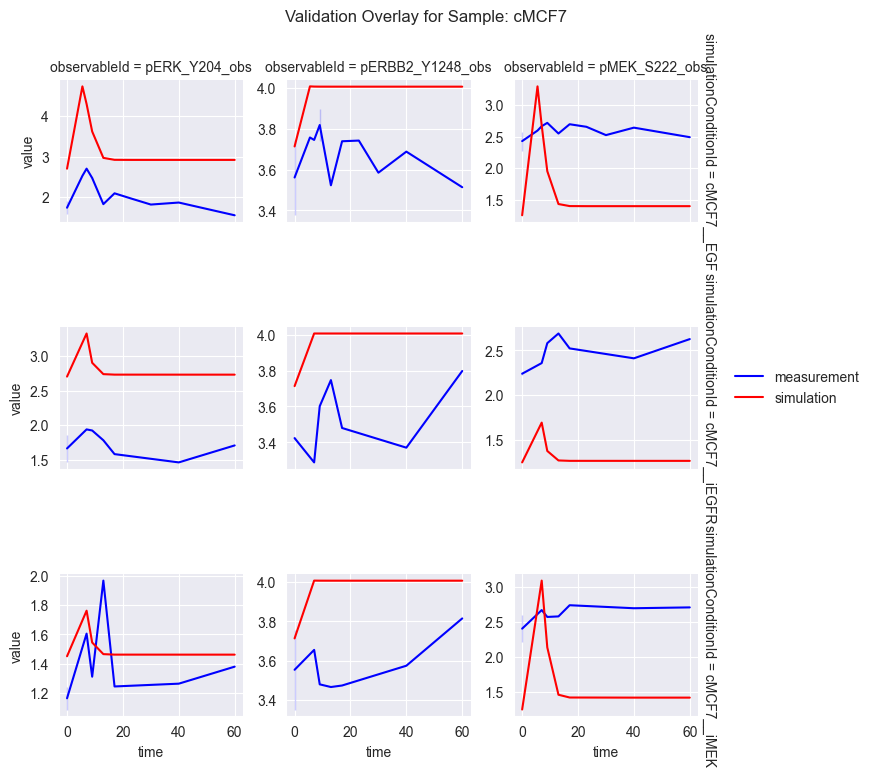


===== CV split: 1of5 =====
Training RMSE: 0.681, Validation RMSE: 1.803


Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualizat

Train simulation RMSE: 1.193


Visualization table not available. Skipping.


Val simulation RMSE: 1.924


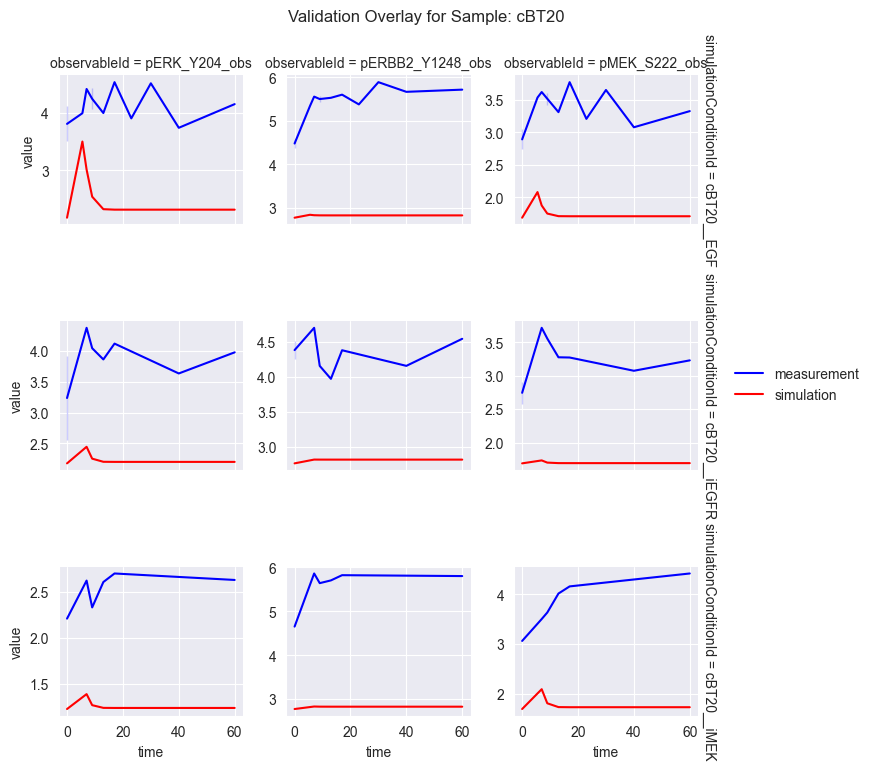


===== CV split: 2of5 =====
Training RMSE: 0.661, Validation RMSE: 1.672


Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualizat

Train simulation RMSE: 1.190


Visualization table not available. Skipping.


Val simulation RMSE: 1.142


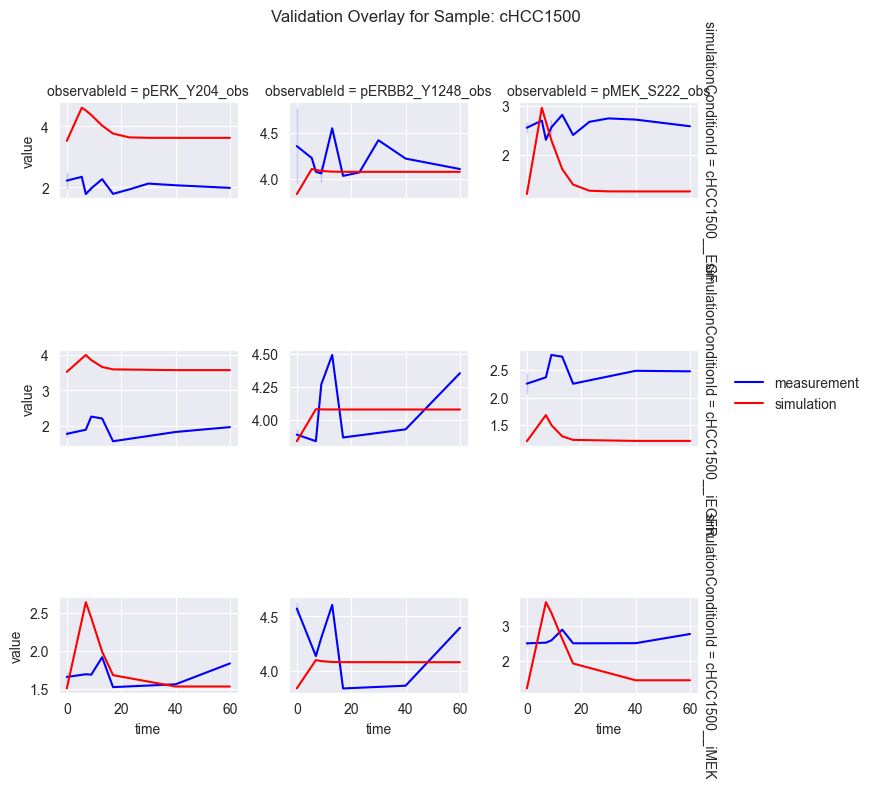


===== CV split: 3of5 =====
Training RMSE: 0.657, Validation RMSE: 1.835


Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualizat

Train simulation RMSE: 1.185


Visualization table not available. Skipping.


Val simulation RMSE: 1.322


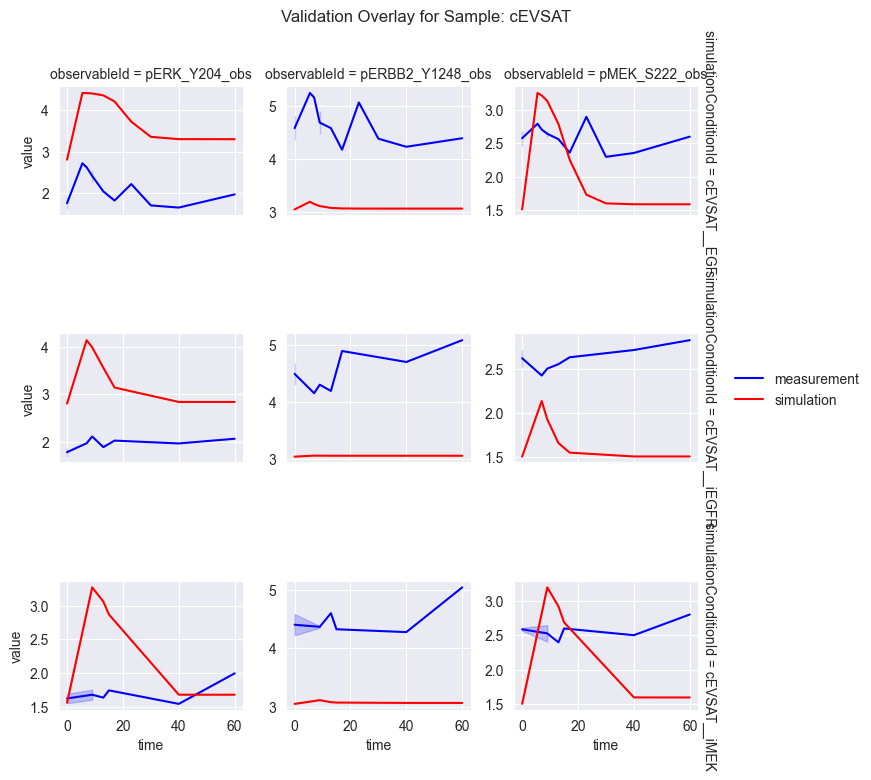


===== CV split: 4of5 =====
Training RMSE: 0.672, Validation RMSE: 1.823


Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualization table not available. Skipping.
Visualizat

Train simulation RMSE: 1.181


Visualization table not available. Skipping.


Val simulation RMSE: 1.451


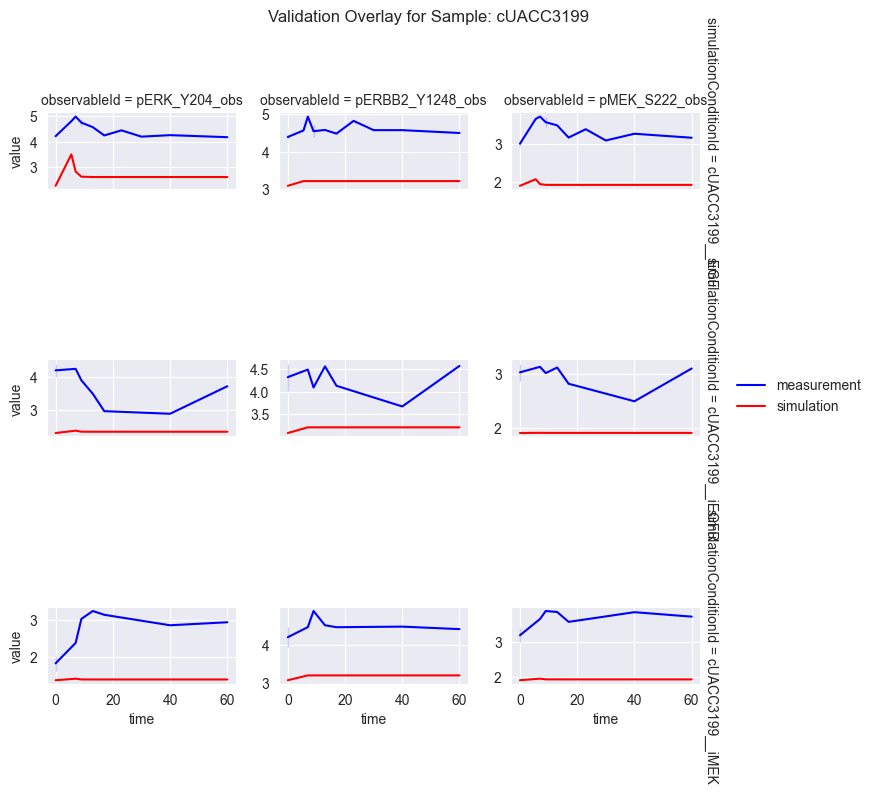

In [4]:
# Load PEtab files once
petab_files_all = load_petab_base_files(conf)
del petab_files_all["condition_table"]

rmse_dict = {}

# Train Random Forest on each split, predict parameters and simulate
for split in [f"{i}of5" for i in range(5)]:
    print(f"\n===== CV split: {split} =====")
    conf = Conf(model="EGFR_MAPK", data="dream_cytof", samples=split)
    samples_train, samples_val = training_samples(conf), val_samples(conf)
    rmse_dict[split] = {}

    train_targets = par_combo[par_combo.index.isin(samples_train)]
    val_targets = par_combo[par_combo.index.isin(samples_val)]

    input_train, features_train, _, imputer = load_data(
        contextualization="cytof_init",
        samples=samples_train,
        features=None,
        **petab_files_all,
    )

    input_val, _, _, _ = load_data(
        contextualization="cytof_init",
        samples=samples_val,
        features=features_train,
        imputer=imputer,
        **petab_files_all,
    )

    rf = RandomForestRegressor()
    rf.fit(input_train.values, train_targets.values)

    train_pred = rf.predict(input_train.values)
    val_pred = rf.predict(input_val.values)

    train_rmse = np.sqrt(np.mean((train_pred - train_targets.values) ** 2))
    val_rmse = np.sqrt(np.mean((val_pred - val_targets.values) ** 2))
    print(f"Training RMSE: {train_rmse:.3f}, Validation RMSE: {val_rmse:.3f}")

    rmse_dict[split]["params_train"] = train_rmse
    rmse_dict[split]["params_val"] = val_rmse

    # Simulate given regressed parameters
    ref_conf = Conf(model=conf.model, data=conf.data, max_lrate=0, lrate_span=0, lrate_decay=0)
    petab_base_files = load_petab_base_files(conf)
    problem = CytofProblem(conf.model)
    petab_base_importer = load_petab(problem, conf.data, **petab_base_files)

    for sample_set, prediction, set_name in [
        (samples_train, train_pred, "train"),
        (samples_val, val_pred, "val"),
    ]:
        evaluations = []

        for i, sample in enumerate(sample_set):
            importer = generate_per_sample_pretraining_problems(
                petab_base_importer,
                problem,
                conf.data,
                sample,
            )
            problem_sample = importer.create_problem()
            problem.apply_objective_settings(problem_sample.objective)

            pred_df = pd.DataFrame(
                prediction[i:i+1],
                columns=par_combo.columns,
            )

            x = problem_sample.get_reduced_vector(
                pred_df.values.reshape(-1, ), problem_sample.x_free_indices
            )

            res = problem_sample.objective(x, return_dict=True)

            simulation_df = rdatas_to_simulation_df(
                res["rdatas"],
                model=problem_sample.objective.amici_model,
                measurement_df=importer.petab_problem.measurement_df,
            )

            process_simulation(
                evaluations=evaluations,
                measurement_df=importer.petab_problem.measurement_df,
                simulation_df=simulation_df,
                conf=ref_conf,
                sample=sample,
            )

        eval_df = pd.DataFrame(evaluations)
        overall_rmse = np.sqrt(np.mean(np.square(eval_df["res"])))
        print(f"{set_name.capitalize()} simulation RMSE: {overall_rmse:.3f}")
        rmse_dict[split][set_name] = overall_rmse

        if set_name == "val":  # Only plot for validation samples
            for i, sample in enumerate(sample_set):
                importer = generate_per_sample_pretraining_problems(
                    petab_base_importer,
                    problem,
                    conf.data,
                    sample,
                )
                problem_sample = importer.create_problem()
                problem.apply_objective_settings(problem_sample.objective)

                pred_df = pd.DataFrame(
                    prediction[i:i+1],
                    columns=par_combo.columns,
                )

                x = problem_sample.get_reduced_vector(
                    pred_df.values.reshape(-1, ), problem_sample.x_free_indices
                )

                res = problem_sample.objective(x, return_dict=True)

                # Get simulation and measurement DataFrames
                sim_df = rdatas_to_simulation_df(
                    res["rdatas"],
                    model=problem_sample.objective.amici_model,
                    measurement_df=importer.petab_problem.measurement_df,
                )
                sim_df["source"] = "simulation"
                sim_df.rename(columns={"simulation": "value"}, inplace=True)

                meas_df = importer.petab_problem.measurement_df.copy()
                meas_df["value"] = meas_df["measurement"]
                meas_df["source"] = "measurement"

                # Merge (overlay) and plot
                combined = pd.concat([
                    meas_df[["time", "observableId", "simulationConditionId", "value", "source"]],
                    sim_df[["time", "observableId", "simulationConditionId", "value", "source"]],
                ])

                g = sns.FacetGrid(
                    combined,
                    col="observableId",
                    row="simulationConditionId",
                    margin_titles=True,
                    height=2.5,
                    sharey=False,
                )
                g.map_dataframe(
                    sns.lineplot,
                    x="time",
                    y="value",
                    hue="source",
                    palette={"measurement": "blue", "simulation": "red"},
                )
                g.add_legend()
                g.fig.suptitle(f"Validation Overlay for Sample: {sample}", y=1.02)
                plt.show()

In [6]:
rmse_dict

{'0of5': {'params_train': 0.6605996776354061,
  'params_val': 1.1027452396928148,
  'train': 1.1727673608624203,
  'val': 0.8922468328438445},
 '1of5': {'params_train': 0.6806431711771705,
  'params_val': 1.8028986498821986,
  'train': 1.1926950305173913,
  'val': 1.924150996802874},
 '2of5': {'params_train': 0.6612208968455802,
  'params_val': 1.6717508177595997,
  'train': 1.1903358476862789,
  'val': 1.1416111337491812},
 '3of5': {'params_train': 0.6567733576162995,
  'params_val': 1.8353249851022062,
  'train': 1.1852341739895005,
  'val': 1.3220394700659457},
 '4of5': {'params_train': 0.6723218062932812,
  'params_val': 1.8229024369312348,
  'train': 1.1806433679099433,
  'val': 1.4514707875269248}}